The gene expression dataset was loaded into a Pandas DataFrame. The gene names were set as the index to facilitate analysis and preprocessing.

In [ ]:
import pandas as pd

df = pd.read_csv("RNA_seq_1.csv")

df = df.set_index("attrib_name")
df.index.name = 'gene_name'

df.head()

,TCGA.02.0001,TCGA.02.0003,TCGA.02.0004,TCGA.02.0007,TCGA.02.0009,TCGA.02.0010,TCGA.02.0011,TCGA.02.0014,TCGA.02.0015,TCGA.02.0016,...,TCGA.76.4932,TCGA.76.4934,TCGA.76.4935,TCGA.76.6191,TCGA.76.6192,TCGA.76.6193,TCGA.76.6282,TCGA.76.6285,TCGA.81.5910,TCGA.87.5896
gene_name,,,,,,,,,,,,,,,,,,,,,
AACS,6.5006,6.5392,7.3778,7.1869,7.6750,7.9960,8.3551,6.8401,6.3491,6.2900,...,5.8965,6.3478,6.1927,7.2218,7.5393,6.9078,7.0076,7.6763,7.1052,7.2302
FSTL1,8.7297,9.7944,12.0596,4.9451,10.8401,8.9316,4.2406,7.7385,10.7565,9.6489,...,8.1148,8.8745,9.9205,10.1363,9.8328,11.0918,10.7895,9.6826,9.8474,10.4376
ELMO2,5.5114,6.2140,7.0517,5.2304,6.6207,7.5524,6.7073,7.2623,7.1187,7.9180,...,7.3827,6.8193,6.6757,7.7135,7.6458,7.8877,7.5698,7.0198,7.5335,7.9569
CREB3L1,4.8830,4.8363,6.1124,5.8186,5.3332,6.0873,4.8655,4.5245,4.8251,4.8311,...,4.6810,5.6369,5.3315,5.0622,5.5533,4.6878,5.3670,4.6857,6.1549,6.8131
RPS11,10.9848,10.8112,10.4364,10.4773,10.6373,11.0015,10.6859,10.6613,10.2849,10.2522,...,10.9302,10.4001,10.3514,10.6369,10.5655,10.4751,10.5730,10.4392,10.6853,10.3156


The shape of the dataset was examined to determine the number of genes and samples available for analysis.

In [ ]:
df.shape

(4571, 528)

Data types were checked to ensure that all gene expression values were numeric and suitable for statistical analysis and clustering.

In [ ]:
df.dtypes

,0
TCGA.02.0001,float64
TCGA.02.0003,float64
TCGA.02.0004,float64
TCGA.02.0007,float64
TCGA.02.0009,float64
...,...
TCGA.76.6193,float64
TCGA.76.6282,float64
TCGA.76.6285,float64
TCGA.81.5910,float64


Descriptive statistics were generated to understand the distribution, central tendency, and variability of gene expression values.

In [ ]:
df.describe()

,TCGA.02.0001,TCGA.02.0003,TCGA.02.0004,TCGA.02.0007,TCGA.02.0009,TCGA.02.0010,TCGA.02.0011,TCGA.02.0014,TCGA.02.0015,TCGA.02.0016,...,TCGA.76.4932,TCGA.76.4934,TCGA.76.4935,TCGA.76.6191,TCGA.76.6192,TCGA.76.6193,TCGA.76.6282,TCGA.76.6285,TCGA.81.5910,TCGA.87.5896
count,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,4571.000000,...,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000,4570.000000
mean,5.984879,6.138479,6.366215,6.094556,6.228164,6.110623,6.185587,6.235158,6.256211,6.247381,...,6.286312,6.155488,6.099155,6.658716,6.675037,6.677863,6.606491,6.695264,6.592005,6.733345
std,1.728516,1.879417,2.082473,1.939755,1.941639,1.879027,2.021023,2.027263,2.035121,1.980385,...,1.991549,1.841127,1.814975,2.105439,2.085283,2.118130,2.082138,2.152357,2.109960,2.155766
min,3.232000,3.219700,3.256400,3.090300,2.795300,3.240200,3.011900,3.383900,3.344000,3.292800,...,3.364100,3.289200,3.286300,3.268300,3.218300,3.248500,3.278800,3.236600,3.249000,3.317400
25%,4.650600,4.581400,4.485100,4.568500,4.582350,4.594100,4.459500,4.452300,4.472400,4.473150,...,4.513275,4.559450,4.552000,4.694600,4.721400,4.653075,4.639625,4.606175,4.558000,4.629650
50%,5.553100,5.733000,6.054100,5.514000,5.851500,5.637400,5.677700,5.768400,5.874400,5.930200,...,6.013050,5.892650,5.824400,6.686800,6.725500,6.751950,6.630050,6.721200,6.600050,6.835900
75%,6.904150,7.305250,7.802850,7.233150,7.490600,7.204400,7.562450,7.622350,7.601200,7.598450,...,7.646000,7.316975,7.182575,8.141550,8.119500,8.172250,8.074250,8.187575,8.089375,8.254875
max,13.575200,13.301600,13.576300,13.556400,13.438100,13.523100,13.668300,13.790100,13.497100,13.371000,...,13.613700,12.834700,13.080100,13.735100,13.684000,13.764200,13.909100,13.584200,13.715300,13.817200


The dataset was checked for duplicate records, and no duplicates were found.

In [ ]:
df.duplicated().sum()

np.int64(0)

We checked for missing values in the dataset and found some null entries that needed to be handled.

In [ ]:
df.isnull().sum().sum()

np.int64(191)

Skewness was calculated to evaluate the symmetry of gene expression distributions. Most genes exhibited mild skewness, indicating that standardization would be appropriate.

In [ ]:
df.skew()

,0
TCGA.02.0001,1.155188
TCGA.02.0003,0.910195
TCGA.02.0004,0.657022
TCGA.02.0007,1.055324
TCGA.02.0009,0.831729
...,...
TCGA.76.6193,0.332537
TCGA.76.6282,0.420000
TCGA.76.6285,0.337460
TCGA.81.5910,0.431090


Histograms were used to understand the distribution of gene expression values and check for skewness.

array([[<Axes: title={'center': 'EREG'}>,
        <Axes: title={'center': 'GNB2'}>],
       [<Axes: title={'center': 'WSB1'}>,
        <Axes: title={'center': 'WDR47'}>],
       [<Axes: title={'center': 'MAGEA11'}>, <Axes: >]], dtype=object)

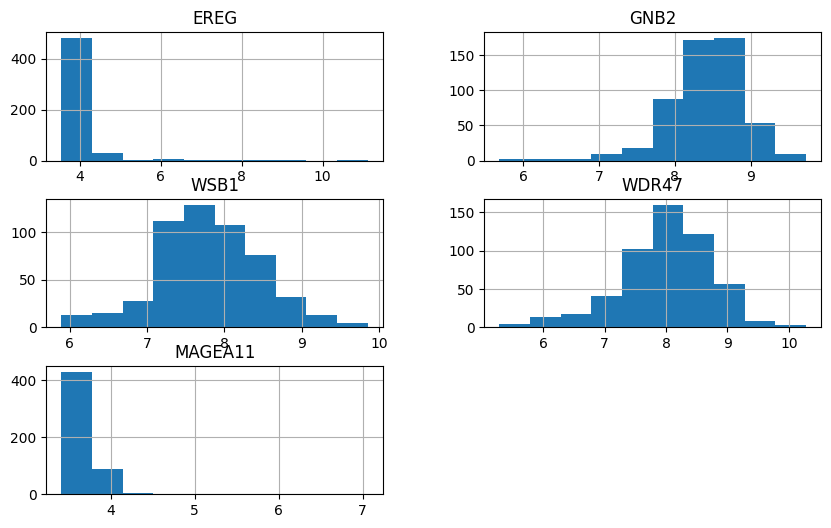

In [ ]:
df.sample(5).T.hist(figsize=(10,6))

Boxplots were used to detect outliers. Some outliers were observed, which is expected in gene expression data due to biological variability. Therefore, outliers were retained to preserve important information.

<Axes: >

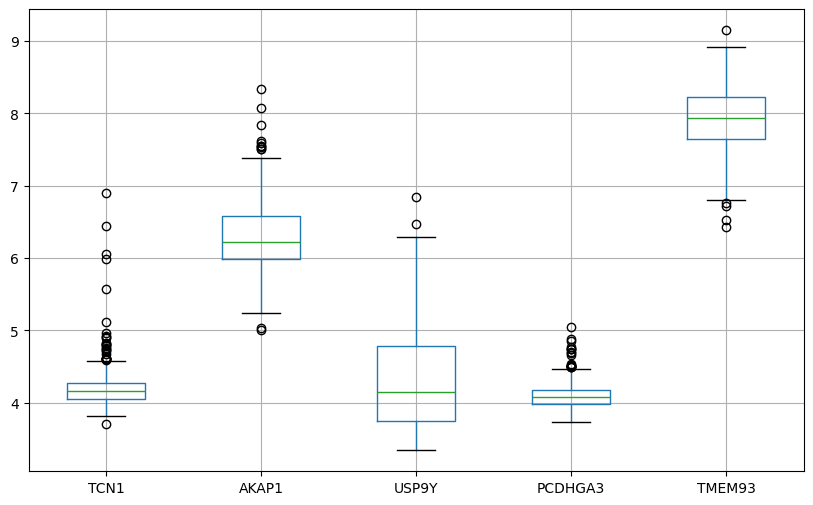

In [ ]:
df.sample(5).T.boxplot(figsize=(10,6))

The nunique function was used to verify that each sample contains diverse gene expression values and is not constant, ensuring meaningful variability for analysis.

In [ ]:
df.nunique()

,0
TCGA.02.0001,4365
TCGA.02.0003,4401
TCGA.02.0004,4410
TCGA.02.0007,4367
TCGA.02.0009,4398
...,...
TCGA.76.6193,4410
TCGA.76.6282,4420
TCGA.76.6285,4412
TCGA.81.5910,4415


Mean imputation was chosen because the dataset consists of continuous gene expression values with mild skewness and no extreme outliers, making mean a simple and effective method without losing data.

In [ ]:
df = df.apply(lambda x: x.fillna(x.mean()), axis=1)

The dataset was rechecked after imputation to confirm that all missing values had been successfully handled.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

Constant features were checked because features with no variation do not contribute useful information to clustering.

In [ ]:
(df.nunique() == 1).sum()

np.int64(0)

The dataset was transposed to align with machine learning requirements where rows represent samples and columns represent features. This ensures clustering is performed on patient samples rather than genes.

In [ ]:
df = df.T

After transposition, the dataset contained 528 samples and 4571 gene features, making it suitable for machine learning analysis.

In [ ]:
df.shape


(528, 4571)

In [ ]:
df.head()

gene_name,AACS,FSTL1,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,SAMD4A,SMARCD3,A4GNT,...,CNTD2,OCLM,ZSCAN18,MYL4,SLC17A1,TAF5L,L3MBTL,TSTA3,CCDC59,RAC1
TCGA.02.0001,6.5006,8.7297,5.5114,4.8830,10.9848,7.5352,8.6740,5.0326,4.7110,5.1085,...,5.3734,4.0452,5.9452,5.2649,3.7023,6.2648,4.2333,8.1816,7.1473,11.7460
TCGA.02.0003,6.5392,9.7944,6.2140,4.8363,10.8112,6.9979,9.3486,5.0270,5.3277,4.3486,...,5.1081,4.0367,6.4729,4.9223,3.5371,6.3724,4.2408,7.4861,8.2772,11.4917
TCGA.02.0004,7.3778,12.0596,7.0517,6.1124,10.4364,9.1321,11.2485,5.5591,8.2682,4.0524,...,4.6046,3.8521,7.2389,5.3657,3.6313,6.3536,4.0206,7.5645,8.4564,12.2318
TCGA.02.0007,7.1869,4.9451,5.2304,5.8186,10.4773,8.3561,4.4295,5.1759,4.4405,4.8242,...,5.3337,4.5189,5.7233,5.6326,3.9954,5.9280,4.3378,8.1142,8.9638,11.1089
TCGA.02.0009,7.6750,10.8401,6.6207,5.3332,10.6373,6.9429,9.4522,5.1649,4.9522,4.2046,...,5.2383,3.9431,5.9389,5.3012,3.6754,6.2691,4.2926,7.5337,8.1234,11.8188


# **FEATURE SCALING**

Standardization was chosen because it preserves the distribution and variability of gene expression data, whereas normalization may compress important differences.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
df_scaled = pd.DataFrame(df_scaled, index=df.index, columns=df.columns)

In [ ]:
df_scaled

gene_name,AACS,FSTL1,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,SAMD4A,SMARCD3,A4GNT,...,CNTD2,OCLM,ZSCAN18,MYL4,SLC17A1,TAF5L,L3MBTL,TSTA3,CCDC59,RAC1
TCGA.02.0001,-0.604793,-1.016190,-2.203451,0.172469,0.663795,-2.431981,0.808452,-1.404312,-3.484379,3.665084,...,2.401888,0.262914,-2.388429,0.414709,0.124176,0.454864,-0.538850,2.509203,-1.386086,-1.173508
TCGA.02.0003,-0.533315,0.046649,-1.181452,0.079552,0.219227,-3.089855,1.405718,-1.419007,-2.885355,-0.167505,...,1.411292,0.219039,-1.659601,-0.949910,-0.902119,0.716256,-0.504724,1.034193,0.560472,-2.022345
TCGA.02.0004,1.019574,2.307890,0.037064,2.618555,-0.740590,-0.476726,3.087820,-0.022720,-0.029135,-1.661402,...,-0.468713,-0.733819,-0.601647,0.816208,-0.316907,0.670585,-1.506663,1.200463,0.869192,0.448062
TCGA.02.0007,0.666072,-4.794176,-2.612193,2.033993,-0.635850,-1.426866,-2.949471,-1.028278,-3.747126,2.231204,...,2.253653,2.708031,-2.694904,1.879305,1.945042,-0.363325,-0.063361,2.366262,1.743326,-3.300108
TCGA.02.0009,1.569918,1.090521,-0.589867,1.068213,-0.226110,-3.157197,1.497442,-1.057143,-3.250092,-0.893775,...,1.897442,-0.264100,-2.397130,0.559297,-0.042939,0.465310,-0.269027,1.135143,0.295510,-0.930506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.76.6193,0.149245,1.341781,1.253107,-0.215913,-0.641484,-0.469134,0.940726,0.768711,-0.623497,-1.632654,...,-1.949566,-1.575699,0.003845,-1.150660,-1.082280,-0.104604,-0.316804,-0.400309,0.408524,0.000000
TCGA.76.6282,0.334051,1.040010,0.790691,1.135463,-0.390774,-0.101935,1.400760,0.030025,0.558039,-0.655216,...,-0.674822,-0.768402,1.182648,-0.516546,-1.264926,-0.314253,-0.650783,0.432949,-0.429087,0.000000
TCGA.76.6285,1.572325,-0.064956,-0.009338,-0.220091,-0.733420,0.835961,0.324867,-0.439166,0.170281,-1.174700,...,-1.510836,-0.590839,0.085056,-1.208814,-0.400775,0.252746,-2.401219,0.518629,0.707769,0.000000
TCGA.81.5910,0.514783,0.099556,0.737889,2.703115,-0.103188,0.856041,-0.607509,1.527865,0.263723,-0.079747,...,-0.939927,0.078123,1.015945,-0.320576,-0.157869,0.006172,-0.176660,1.287840,1.197035,0.000000


The scaled data was verified to have approximately zero mean and unit variance, confirming successful standardization.

In [ ]:
df_scaled.describe().iloc[:, :5]

gene_name,AACS,FSTL1,ELMO2,CREB3L1,RPS11
count,5.280000e+02,5.280000e+02,5.280000e+02,5.280000e+02,5.280000e+02
mean,1.641784e-15,1.345725e-17,2.960595e-16,-4.306320e-16,2.254089e-15
std,1.000948e+00,1.000948e+00,1.000948e+00,1.000948e+00,1.000948e+00
min,-2.389893e+00,-6.074634e+00,-3.048135e+00,-1.721089e+00,-2.770598e+00
25%,-6.421060e-01,-5.137450e-01,-5.260103e-01,-7.608801e-01,-6.636359e-01
50%,-2.324665e-02,9.661135e-02,4.215520e-02,-1.260795e-01,-1.661854e-01
75%,5.822800e-01,6.545595e-01,6.659954e-01,4.764388e-01,4.858780e-01
max,4.754951e+00,2.307890e+00,2.753523e+00,6.612993e+00,3.630572e+00


## Hierarchical Clustering

Hierarchical clustering was performed using Ward linkage. Ward linkage minimizes the increase in within-cluster variance during each merge operation, resulting in compact and homogeneous clusters. The linkage matrix stores information about the clustering process and is later used to generate a dendrogram.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(df_scaled,method ='ward')

## Dendrogram Visualization

A dendrogram was generated to visualize the hierarchical clustering process. By examining the major vertical gaps in the dendrogram, an appropriate number of clusters can be identified.

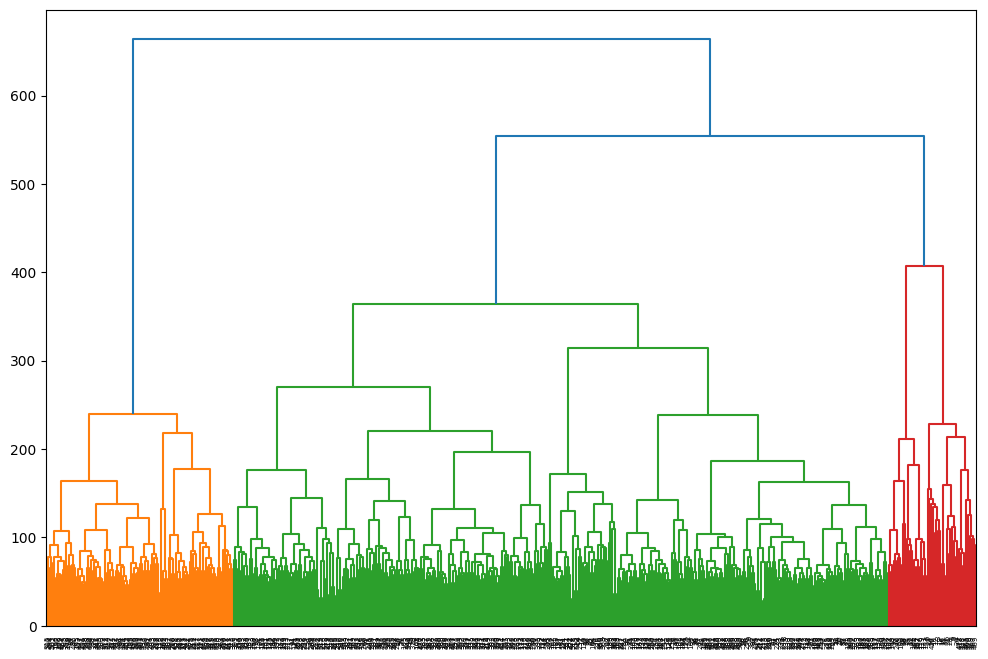

In [ ]:
plt.figure(figsize=(12,8))

dendrogram(linked)
plt.show()


The dendrogram shows the hierarchical relationships among the samples. A horizontal cut through the major gap suggests the presence of three clusters, which were selected for further analysis.

## Cluster Assignment

Based on the dendrogram analysis, three clusters were selected. The fcluster() function was used to assign a cluster label to each sample.

In [ ]:
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linked,t=3,criterion='maxclust')

## Adding Cluster Labels

The generated cluster labels were added to the standardized dataset so that each sample could be associated with its corresponding cluster.

In [ ]:
df_scaled['Cluster'] = clusters

In [ ]:
df_scaled.head()

gene_name,AACS,FSTL1,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,SAMD4A,SMARCD3,A4GNT,...,OCLM,ZSCAN18,MYL4,SLC17A1,TAF5L,L3MBTL,TSTA3,CCDC59,RAC1,Cluster
TCGA.02.0001,-0.604793,-1.016190,-2.203451,0.172469,0.663795,-2.431981,0.808452,-1.404312,-3.484379,3.665084,...,0.262914,-2.388429,0.414709,0.124176,0.454864,-0.538850,2.509203,-1.386086,-1.173508,3
TCGA.02.0003,-0.533315,0.046649,-1.181452,0.079552,0.219227,-3.089855,1.405718,-1.419007,-2.885355,-0.167505,...,0.219039,-1.659601,-0.949910,-0.902119,0.716256,-0.504724,1.034193,0.560472,-2.022345,3
TCGA.02.0004,1.019574,2.307890,0.037064,2.618555,-0.740590,-0.476726,3.087820,-0.022720,-0.029135,-1.661402,...,-0.733819,-0.601647,0.816208,-0.316907,0.670585,-1.506663,1.200463,0.869192,0.448062,2
TCGA.02.0007,0.666072,-4.794176,-2.612193,2.033993,-0.635850,-1.426866,-2.949471,-1.028278,-3.747126,2.231204,...,2.708031,-2.694904,1.879305,1.945042,-0.363325,-0.063361,2.366262,1.743326,-3.300108,3
TCGA.02.0009,1.569918,1.090521,-0.589867,1.068213,-0.226110,-3.157197,1.497442,-1.057143,-3.250092,-0.893775,...,-0.264100,-2.397130,0.559297,-0.042939,0.465310,-0.269027,1.135143,0.295510,-0.930506,3


## Cluster Distribution Analysis

The number of samples belonging to each cluster was calculated to understand the distribution of samples across the identified groups.

In [ ]:
 df_scaled['Cluster'].value_counts()

,count
Cluster,
2,372
1,106
3,50


The clustering process produced three clusters containing 372, 106, and 50 samples respectively. This indicates the presence of one large cluster and two smaller clusters within the dataset.

### Cluster Distribution Analysis

After applying hierarchical clustering and selecting three clusters from the dendrogram, each patient sample was assigned to a cluster. The cluster distribution shows that Cluster 2 contains 372 samples, Cluster 1 contains 106 samples, and Cluster 3 contains 50 samples. This indicates that most patient samples exhibit similar gene expression patterns and belong to Cluster 2, while Clusters 1 and 3 represent smaller groups with distinct expression characteristics. The unequal cluster sizes suggest that the dataset naturally contains one large group and two smaller groups of biologically similar samples.


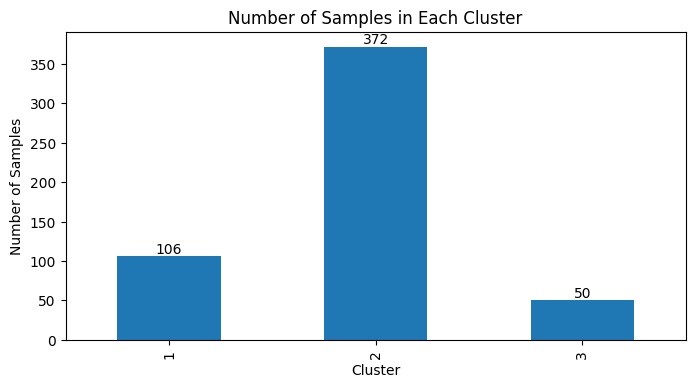

In [ ]:

cluster_counts = df_scaled['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,4))
ax = cluster_counts.plot(kind='bar')

ax.bar_label(ax.containers[0])
plt.title('Number of Samples in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.show()

## Principal Component Analysis (PCA)

Gene expression data contains thousands of features, making direct visualization difficult. Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset from 4571 gene features to 2 principal components while preserving as much variation as possible.

In [ ]:
from sklearn.decomposition import PCA

X = df_scaled.drop('Cluster', axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


## Creating PCA DataFrame

The reduced PCA features were stored in a new DataFrame containing the first two principal components. Cluster labels were then added to facilitate visualization and interpretation of the clustering results.

In [ ]:
import pandas as pd

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

## PCA-Based Cluster Visualization

The first two principal components were plotted to visualize the distribution of samples in a two-dimensional space. Different colors represent the clusters identified through hierarchical clustering.

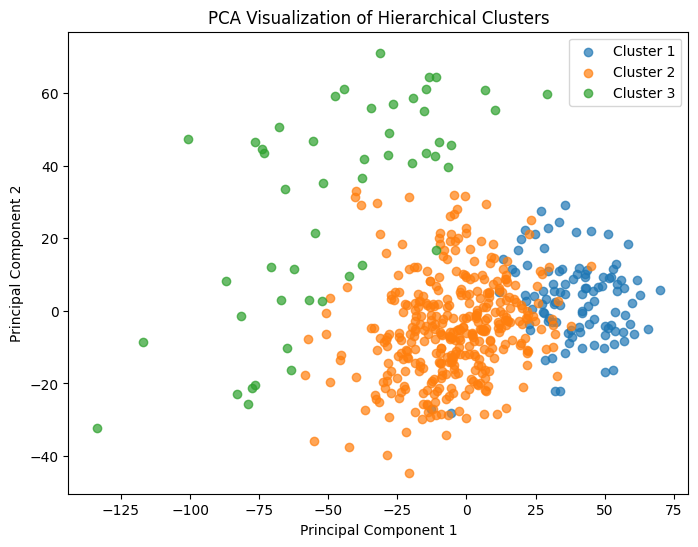

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.title('PCA Visualization of Hierarchical Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

### PCA-Based Cluster Visualization

Principal Component Analysis (PCA) was applied to reduce the high-dimensional gene expression data into two principal components for visualization purposes. The scatter plot displays the distribution of the three clusters identified through hierarchical clustering. Cluster 1 is primarily concentrated on the right side of the plot, Cluster 3 occupies the upper-left region, while Cluster 2 forms the largest group in the central region. Although some overlap exists between clusters, the visualization demonstrates that the clustering algorithm successfully identified distinct patterns within the gene expression data.


## Result Summary

Gene expression data was analyzed using Hierarchical Clustering with Ward linkage and Euclidean distance. After preprocessing, transposition, and standardization, a dendrogram was generated to identify the optimal number of clusters. Three clusters were selected, and all 528 samples were assigned to these clusters. The final cluster distribution consisted of 372, 106, and 50 samples respectively. PCA visualization further demonstrated the separation of samples into distinct groups based on their gene expression patterns.
